# Лабораторна Робота №2
**Тема:** Базові моделі машинного навчання для зображень

In [50]:
import os
import time
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model

In [51]:
output_dir = 'output_lab2'
os.makedirs(output_dir, exist_ok=True)

## 1. Навчання простого класифікатора зображень (MNIST)
### 1.1 - 1.2 Завантаження та попередня обробка

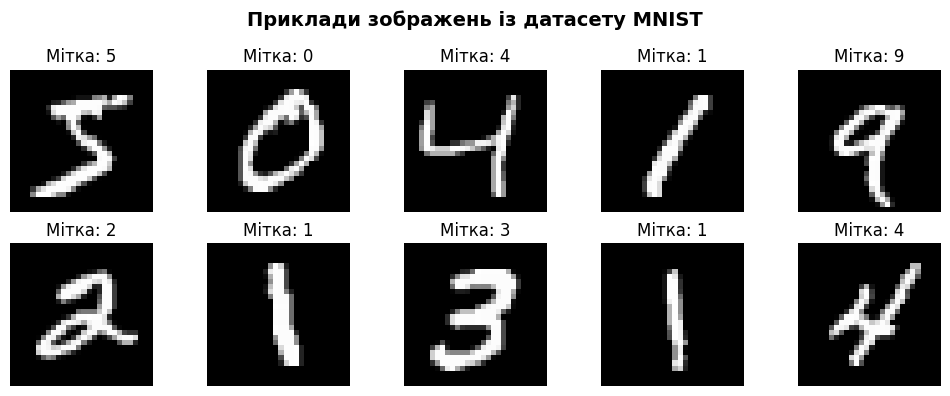

In [52]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()

plt.figure(figsize=(10, 4), facecolor='white')
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[i], cmap='gray')
    plt.title(f'Мітка: {y_train_full[i]}')
    plt.axis('off')
plt.suptitle("Приклади зображень із датасету MNIST", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'mnist_10_examples.png'), dpi=150)
plt.show()

In [53]:
x_flat = x_train_full.reshape((x_train_full.shape[0], -1))
x_test_flat = x_test_full.reshape((x_test_full.shape[0], -1))

x_norm = x_flat.astype("float32") / 255.0
x_test_norm = x_test_flat.astype("float32") / 255.0

x_train, x_val, y_train, y_val = train_test_split(
    x_norm, y_train_full, test_size=0.2, random_state=42
)

scaler = StandardScaler(with_mean=False)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test_norm)

subset_size = 10000
x_train_sub = x_train_scaled[:subset_size]
y_train_sub = y_train[:subset_size]

print(f"Форма тренувальних даних (MLP): {x_train.shape}")
print(f"Форма тренувальних даних (sub-вибірка для SVM/KNN): {x_train_sub.shape}")

Форма тренувальних даних (MLP): (48000, 784)
Форма тренувальних даних (sub-вибірка для SVM/KNN): (10000, 784)


### 1.3.1 Логістична регресія

In [54]:
results = {}

clf_logreg = LogisticRegression(solver="saga", max_iter=200, verbose=0)

t0 = time.time()
clf_logreg.fit(x_train_sub, y_train_sub)
train_time_lr = time.time() - t0

t0 = time.time()
y_pred_logreg = clf_logreg.predict(x_test_scaled)
pred_time_lr = time.time() - t0

acc_lr = accuracy_score(y_test_full, y_pred_logreg)
results["LogReg"] = {"acc": acc_lr, "train_time": train_time_lr, "pred_time": pred_time_lr}

print(f"Точність Logistic Regression: {acc_lr:.4f} (Навчання: {train_time_lr:.2f} сек)")

Точність Logistic Regression: 0.9131 (Навчання: 66.46 сек)


d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### 1.3.2 Одношаровий MLP у Keras

In [55]:
model_mlp = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

t0 = time.time()
history_mlp = model_mlp.fit(
    x_train, y_train,
    epochs=10, batch_size=128,
    validation_data=(x_val, y_val),
    verbose=0
)
train_time_mlp = time.time() - t0

t0 = time.time()
probs_mlp = model_mlp.predict(x_test_norm, verbose=0)
y_pred_mlp = np.argmax(probs_mlp, axis=1)
pred_time_mlp = time.time() - t0

test_loss_mlp, test_acc_mlp = model_mlp.evaluate(x_test_norm, y_test_full, verbose=0)
results["MLP"] = {"acc": test_acc_mlp, "train_time": train_time_mlp, "pred_time": pred_time_mlp}

print(f"Точність MLP: {test_acc_mlp:.4f} (Навчання: {train_time_mlp:.2f} сек)")

Точність MLP: 0.9769 (Навчання: 8.38 сек)


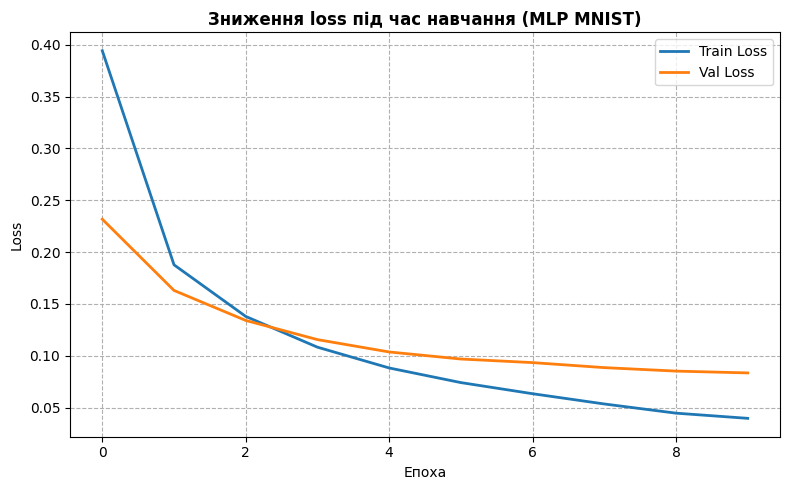

In [56]:
plt.figure(figsize=(8, 5), facecolor='white')
plt.plot(history_mlp.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history_mlp.history['val_loss'], label='Val Loss', linewidth=2)
plt.title('Зниження loss під час навчання (MLP MNIST)', fontweight='bold')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'mnist_mlp_loss.png'), dpi=150)
plt.show()

### 1.4 Передбачення та візуалізація результатів (Аналіз помилок MNIST)

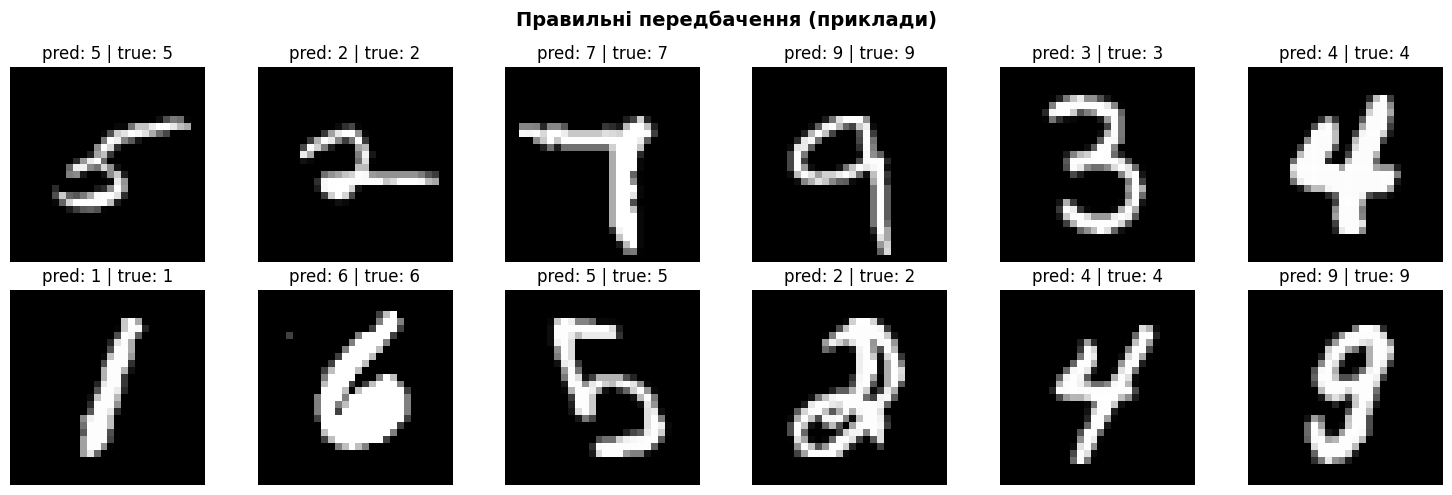

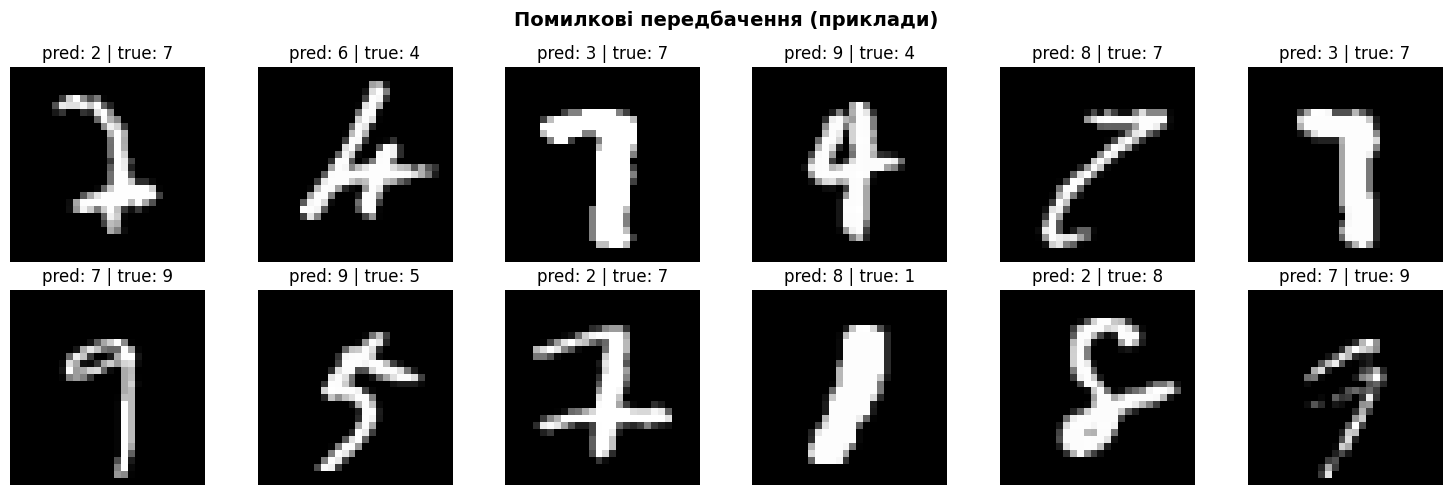

In [57]:
correct_idx = np.where(y_pred_mlp == y_test_full)[0]
incorrect_idx = np.where(y_pred_mlp != y_test_full)[0]

def show_grid(indices, title, n=12):
    n = min(n, len(indices))
    sel = np.random.choice(indices, size=n, replace=False) if len(indices) > n else indices
    cols = 6
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(2.5 * cols, 2.5 * rows), facecolor='white')
    for i, idx in enumerate(sel, 1):
        img = x_test_full[idx]
        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap="gray")
        plt.title(f"pred: {y_pred_mlp[idx]} | true: {y_test_full[idx]}")
        plt.axis("off")
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'mnist_{title[:5]}.png'), dpi=150)
    plt.show()

show_grid(correct_idx, "Правильні передбачення (приклади)", n=12)
show_grid(incorrect_idx, "Помилкові передбачення (приклади)", n=12)

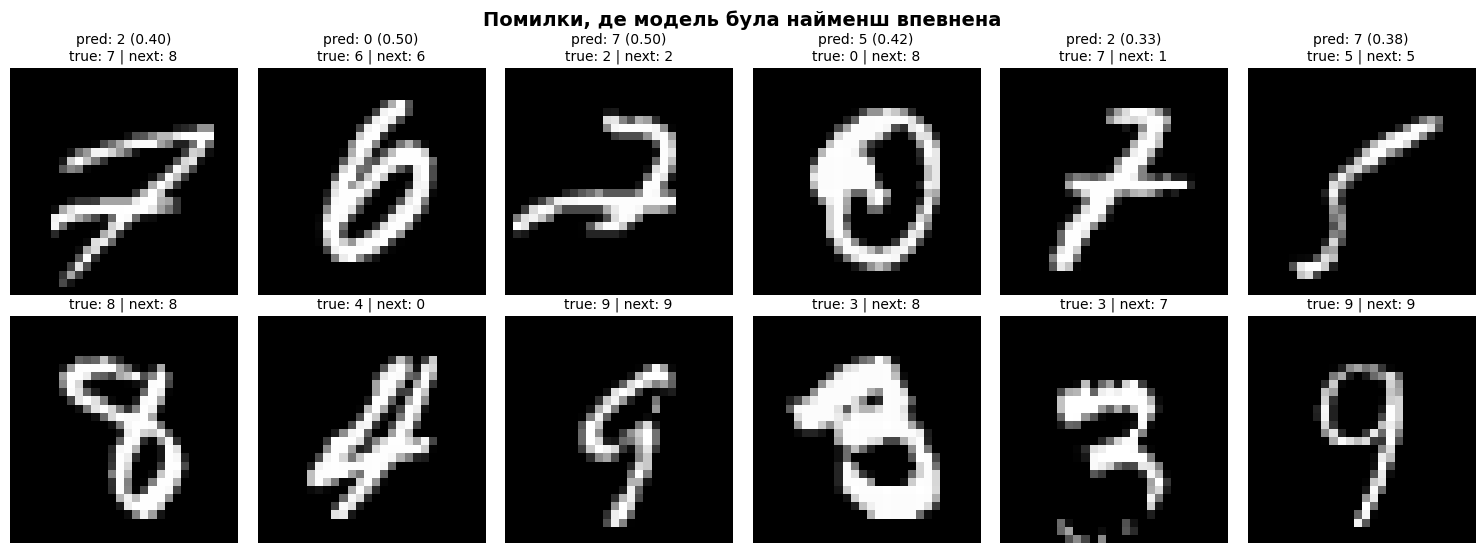

In [58]:
if len(incorrect_idx) > 0:
    margins = []
    for idx in incorrect_idx:
        p = np.sort(probs_mlp[idx])[-2:]
        margins.append((idx, float(p[-1] - p[-2])))
    
    margins = sorted(margins, key=lambda t: t[1])[:12]
    hard_idxs = [idx for idx, _ in margins]

    cols = 6
    rows = int(np.ceil(len(hard_idxs) / cols))
    plt.figure(figsize=(2.5 * cols, 2.8 * rows), facecolor='white')
    for i, idx in enumerate(hard_idxs, 1):
        img = x_test_full[idx]
        top2 = np.argsort(probs_mlp[idx])[-2:][::-1]
        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap='gray')
        plt.title(f"pred: {y_pred_mlp[idx]} ({probs_mlp[idx][y_pred_mlp[idx]]:.2f})\n"
                  f"true: {y_test_full[idx]} | next: {top2[1]}", fontsize=10)
        plt.axis('off')
    plt.suptitle("Помилки, де модель була найменш впевнена", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'mnist_least_confident.png'), dpi=150)
    plt.show()

### 1.5 Порівняння класичних моделей (KNN vs SVM) та загальний бенчмарк

In [59]:
# KNN (k=3)
clf_knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
t0 = time.time()
clf_knn.fit(x_train_sub, y_train_sub)
train_time_knn = time.time() - t0

t0 = time.time()
y_pred_knn = clf_knn.predict(x_test_scaled)
pred_time_knn = time.time() - t0
acc_knn = accuracy_score(y_test_full, y_pred_knn)
results["KNN"] = {"acc": acc_knn, "train_time": train_time_knn, "pred_time": pred_time_knn}
print(f"KNN: Accuracy={acc_knn:.4f}, train={train_time_knn:.2f}s, pred={pred_time_knn:.2f}s")

KNN: Accuracy=0.9127, train=0.01s, pred=1.48s


In [60]:
clf_svm = SVC(kernel="rbf", C=2.0, gamma="scale", random_state=42)
t0 = time.time()
clf_svm.fit(x_train_sub, y_train_sub)
train_time_svm = time.time() - t0

t0 = time.time()
y_pred_svm = clf_svm.predict(x_test_scaled)
pred_time_svm = time.time() - t0
acc_svm = accuracy_score(y_test_full, y_pred_svm)
results["SVM"] = {"acc": acc_svm, "train_time": train_time_svm, "pred_time": pred_time_svm}
print(f"SVM: Accuracy={acc_svm:.4f}, train={train_time_svm:.2f}s, pred={pred_time_svm:.2f}s")

SVM: Accuracy=0.9468, train=14.89s, pred=24.54s


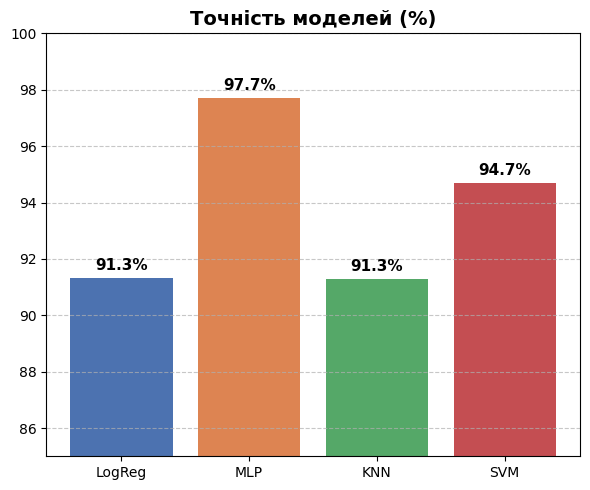

In [61]:
names = list(results.keys())
accuracies = [results[n]["acc"] * 100 for n in names]

plt.figure(figsize=(6, 5), facecolor='white')
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

plt.bar(names, accuracies, color=colors)
plt.title('Точність моделей (%)', fontsize=14, fontweight='bold')
plt.ylim(85, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

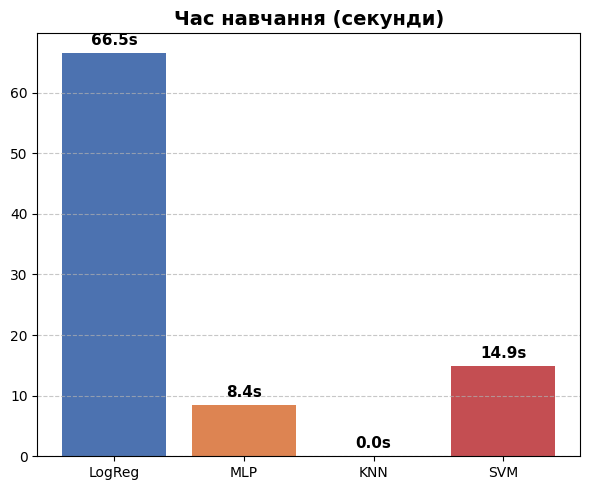

In [62]:
train_times = [results[n]["train_time"] for n in names]

plt.figure(figsize=(6, 5), facecolor='white')

plt.bar(names, train_times, color=colors)
plt.title('Час навчання (секунди)', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(train_times):
    plt.text(i, v + (max(train_times)*0.02), f"{v:.1f}s", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

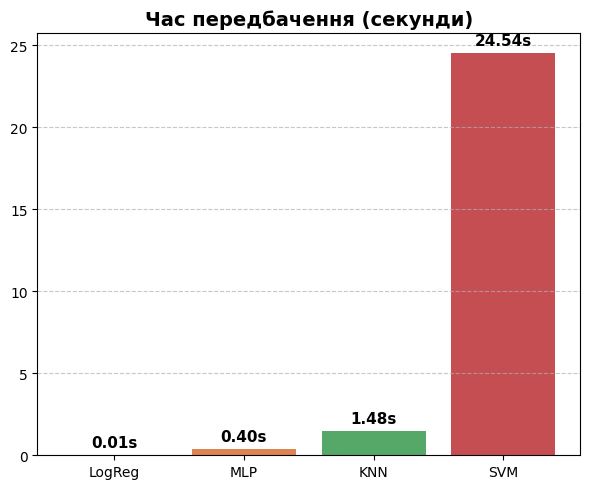

In [63]:
pred_times = [results[n]["pred_time"] for n in names]

plt.figure(figsize=(6, 5), facecolor='white')

plt.bar(names, pred_times, color=colors)
plt.title('Час передбачення (секунди)', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(pred_times):
    plt.text(i, v + (max(pred_times)*0.02), f"{v:.2f}s", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 2. Побудова та тренування простого CNN для CIFAR-10
### 2.1 - 2.3 Підготовка даних, архітектура та навчання CNN

d:\workspace\uni\Masters\CV\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


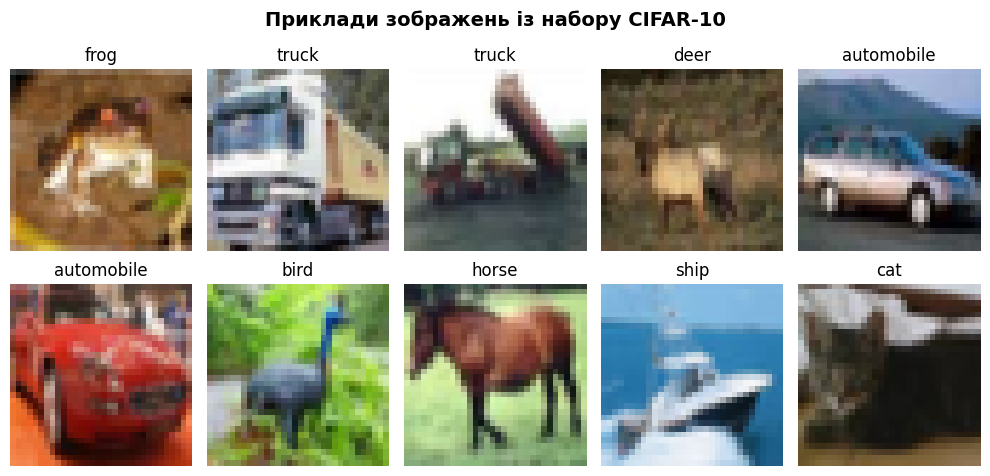

In [64]:
(x_train_c10, y_train_c10), (x_test_c10, y_test_c10) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Візуалізація 10 випадкових прикладів згідно з методичкою (Пункт 2.1)
plt.figure(figsize=(10, 5), facecolor='white')
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_c10[i])
    plt.title(class_names[y_train_c10[i][0]])
    plt.axis("off")
plt.suptitle("Приклади зображень із набору CIFAR-10", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cifar10_10_examples.png'), dpi=150)
plt.show()

In [65]:
x_train_c10 = x_train_c10.astype("float32") / 255.0
x_test_c10 = x_test_c10.astype("float32") / 255.0

y_train_cat = to_categorical(y_train_c10, 10)
y_test_cat = to_categorical(y_test_c10, 10)

In [66]:
model_cnn = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = model_cnn.fit(
    x_train_c10, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.4120 - loss: 1.6004 - val_accuracy: 0.5521 - val_loss: 1.2606
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.5689 - loss: 1.2114 - val_accuracy: 0.6360 - val_loss: 1.0272
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.6337 - loss: 1.0339 - val_accuracy: 0.6650 - val_loss: 0.9408
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.6718 - loss: 0.9283 - val_accuracy: 0.7086 - val_loss: 0.8444
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7056 - loss: 0.8444 - val_accuracy: 0.7262 - val_loss: 0.7775
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7240 - loss: 0.7802 - val_accuracy: 0.7420 - val_loss: 0.7461
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7448 - loss: 0.7288 - val_accuracy: 0.7519 - val_loss: 0.7161
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7592 - loss: 0.6853 - 

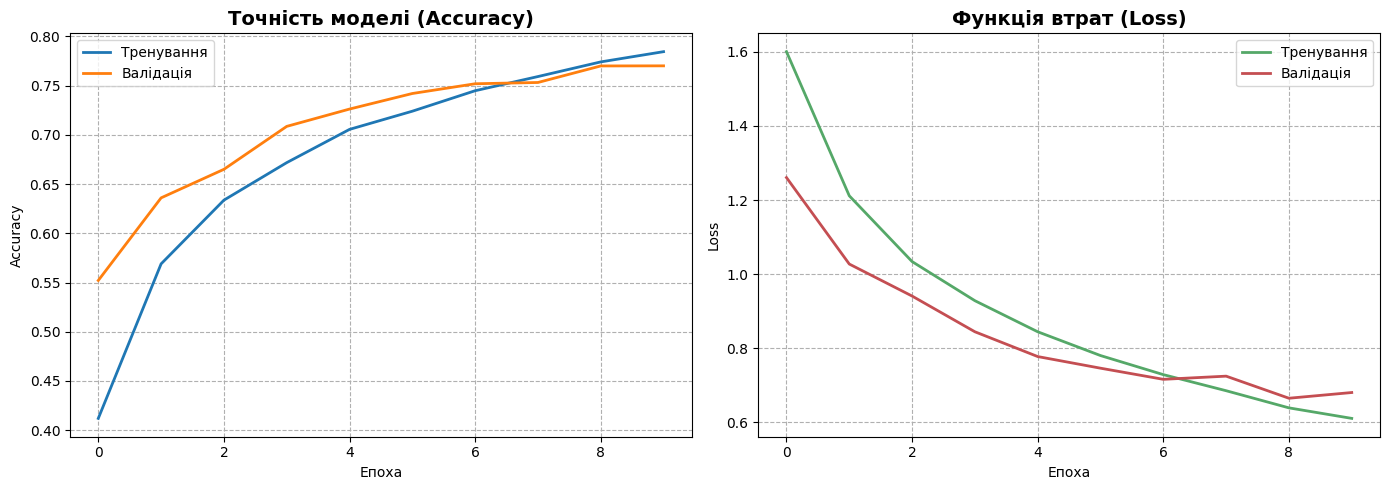

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

axes[0].plot(history_cnn.history['accuracy'], label='Тренування', linewidth=2)
axes[0].plot(history_cnn.history['val_accuracy'], label='Валідація', linewidth=2)
axes[0].set_title('Точність моделі (Accuracy)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--')

axes[1].plot(history_cnn.history['loss'], label='Тренування', linewidth=2, color='#55A868')
axes[1].plot(history_cnn.history['val_loss'], label='Валідація', linewidth=2, color='#C44E52')
axes[1].set_title('Функція втрат (Loss)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cifar10_cnn_history.png'), dpi=150)
plt.show()


### 2.4 Збереження моделі, оцінювання та випадкові передбачення

In [68]:
print("Пункт 2.4.1")
model_path = os.path.join(output_dir, "cnn_cifar10_model.keras")
model_cnn.save(model_path)
print(f"Модель успішно збережена у {model_path}")


Пункт 2.4.1
Модель успішно збережена у output_lab2\cnn_cifar10_model.keras


In [69]:

print("2.4.2 та 2.4.3")
loaded_model = load_model(model_path)
print("Модель успішно завантажена.")


2.4.2 та 2.4.3
Модель успішно завантажена.


In [70]:

train_loss, train_acc = loaded_model.evaluate(x_train_c10, y_train_cat, verbose=0)
test_loss, test_acc = loaded_model.evaluate(x_test_c10, y_test_cat, verbose=0)

print(f"Точність на тренувальних даних: {train_acc:.4f}")
print(f"Точність на тестових даних: {test_acc:.4f}")


Точність на тренувальних даних: 0.8552
Точність на тестових даних: 0.7661


In [71]:

# Зберігаємо у CSV
csv_path = os.path.join(output_dir, "cnn_loaded_results.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["Dataset", "Loss", "Accuracy"])
    writer.writerow(["Train", f"{train_loss:.4f}", f"{train_acc:.4f}"])
    writer.writerow(["Test", f"{test_loss:.4f}", f"{test_acc:.4f}"])
print(f"Результати збережено у {csv_path}")


Результати збережено у output_lab2\cnn_loaded_results.csv


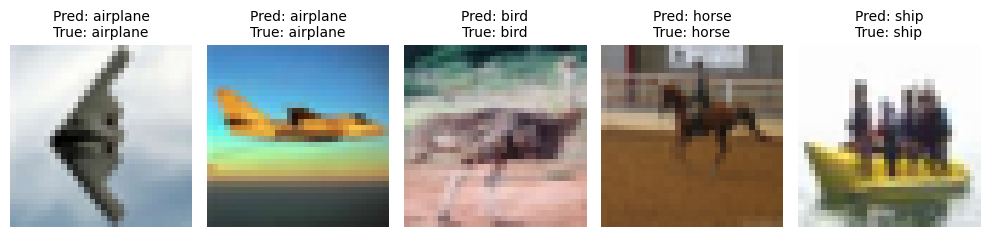

In [72]:

indices = np.random.choice(len(x_test_c10), size=5, replace=False)
images = x_test_c10[indices]
labels_true = np.argmax(y_test_cat[indices], axis=1)
labels_pred = np.argmax(loaded_model.predict(images, verbose=0), axis=1)

plt.figure(figsize=(10, 4), facecolor='white')
for i in range(len(indices)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])
    plt.title(f"Pred: {class_names[labels_pred[i]]}\nTrue: {class_names[labels_true[i]]}", fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cnn_loaded_predictions.png'), dpi=150)
plt.show()


## 3. Оцінка якості моделей 
### 3.1 Classification Report та 3.2 Матриця плутанини

              precision    recall  f1-score   support

    airplane       0.77      0.79      0.78      1000
  automobile       0.88      0.88      0.88      1000
        bird       0.73      0.60      0.66      1000
         cat       0.65      0.55      0.59      1000
        deer       0.73      0.69      0.71      1000
         dog       0.67      0.71      0.69      1000
        frog       0.80      0.84      0.82      1000
       horse       0.76      0.84      0.80      1000
        ship       0.83      0.89      0.86      1000
       truck       0.81      0.88      0.85      1000

    accuracy                           0.77     10000
   macro avg       0.76      0.77      0.76     10000
weighted avg       0.76      0.77      0.76     10000



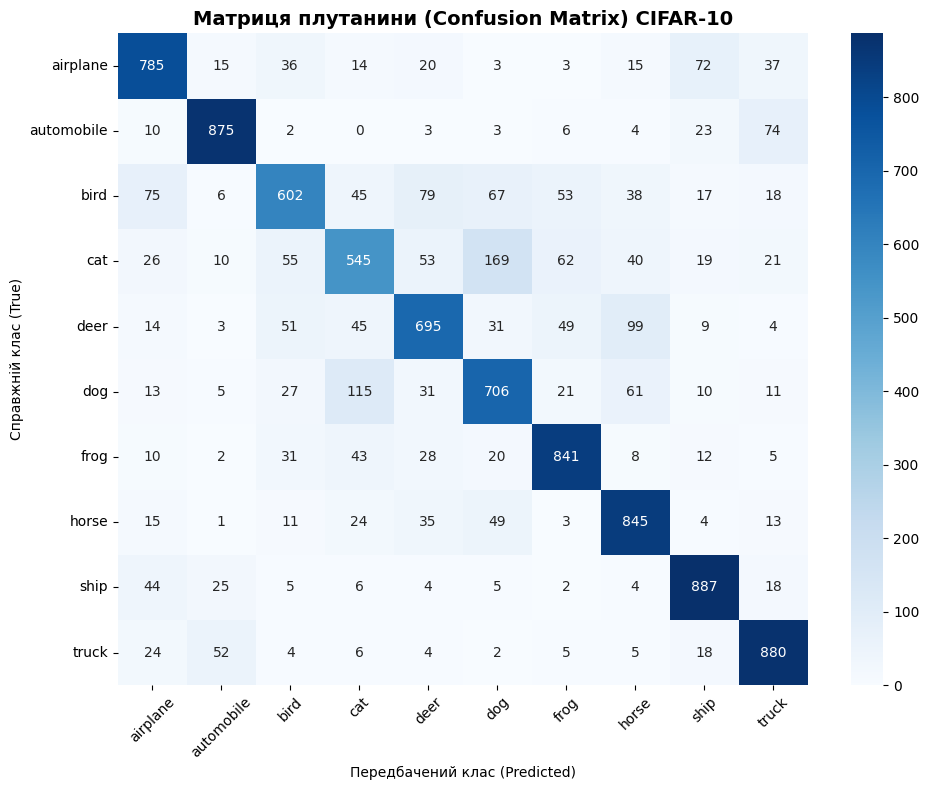

In [73]:
y_pred_probs = loaded_model.predict(x_test_c10, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8), facecolor='white')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матриця плутанини (Confusion Matrix) CIFAR-10', fontsize=14, fontweight='bold')
plt.ylabel('Справжній клас (True)')
plt.xlabel('Передбачений клас (Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cifar10_confusion_matrix.png'), dpi=150)
plt.show()

### 3.3 Власне завдання: Аналіз Топ-10 найвпевненіших помилок моделі

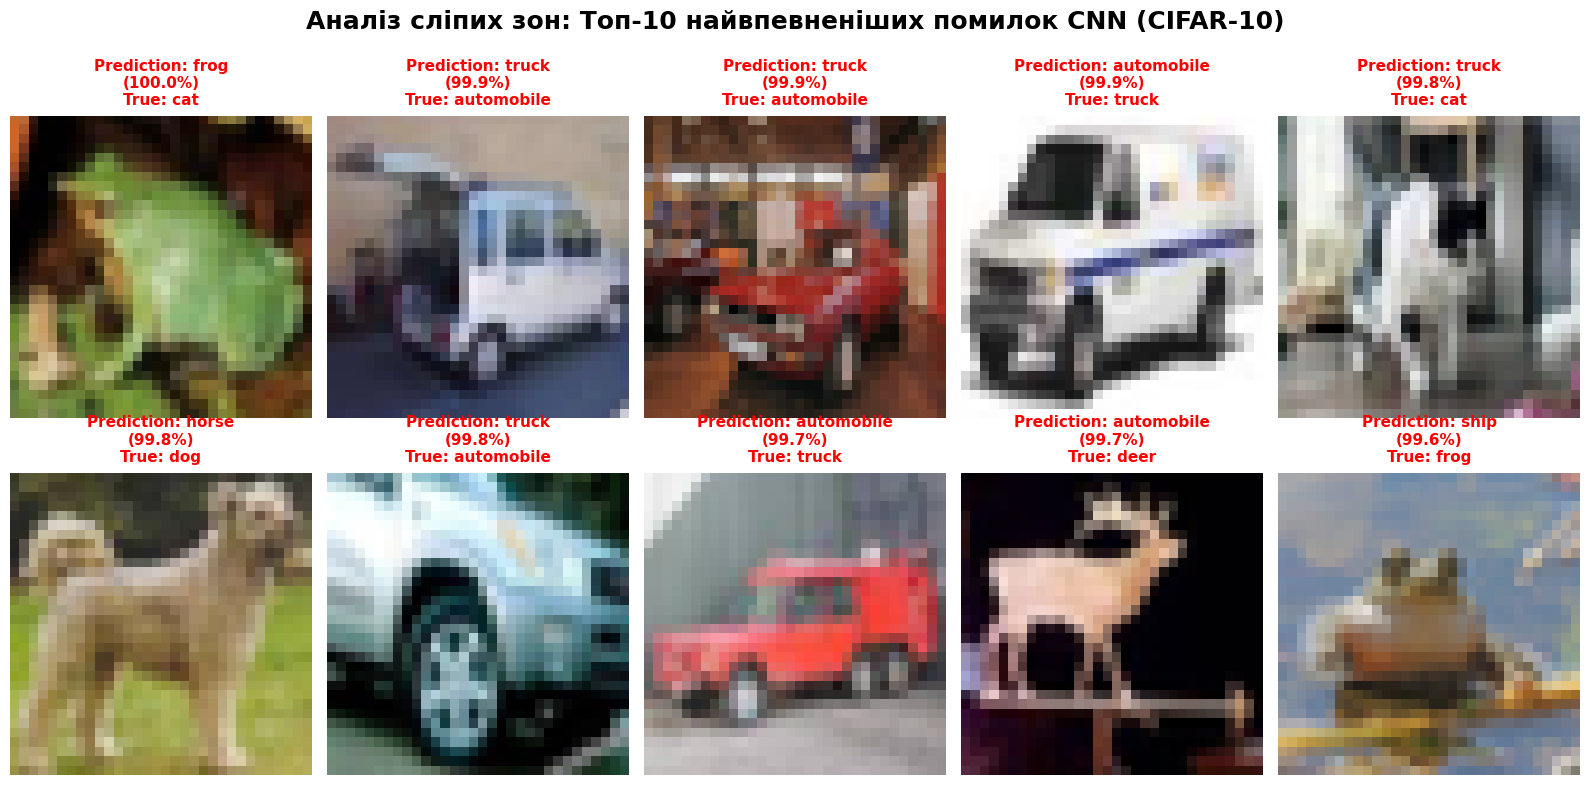

In [74]:
errors_idx = np.where(y_pred_classes != y_true_classes)[0]
error_confidences = y_pred_probs[errors_idx, y_pred_classes[errors_idx]]

sorted_errors_indices = errors_idx[np.argsort(error_confidences)[::-1]]
top_10_errors = sorted_errors_indices[:10]

plt.figure(figsize=(16, 8), facecolor='white') 
plt.suptitle("Аналіз сліпих зон: Топ-10 найвпевненіших помилок CNN (CIFAR-10)", fontsize=18, fontweight='bold')

for i, idx in enumerate(top_10_errors):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_c10[idx])
    pred_label = class_names[y_pred_classes[idx]]
    true_label = class_names[y_true_classes[idx]]
    confidence = y_pred_probs[idx, y_pred_classes[idx]] * 100
    color = 'red' if confidence > 80 else 'black'
    plt.title(f"Prediction: {pred_label}\n({confidence:.1f}%)\nTrue: {true_label}", 
              fontsize=11, color=color, fontweight='bold', pad=8)
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=4.0) 
plt.savefig(os.path.join(output_dir, 'cifar10_top_confident_errors.png'), dpi=150)
plt.show()
